# Imports

In [3]:
!pip install requests pandas matplotlib seaborn

import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import seaborn as sns

Defaulting to user installation because normal site-packages is not writeable


/home/jakob/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


# load data from API
-> last 15 finished Seasons

In [4]:
def get_matches(league, season):
    url = f"https://api.openligadb.de/getmatchdata/{league}/{season}"
    response = requests.get(url)
    return response.json()


LEAGUE = "bl1"
SEASONS = [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

all_matches = []
for season in SEASONS:
    matches = get_matches(LEAGUE, season)
    for m in matches:
        all_matches.append({"season": season, "match": m})

print(f"{len(all_matches)} matches loaded")

4896 matches loaded


# Gather relevant and analyzable matches

In [5]:
records = []

for entry in all_matches:
    m = entry["match"]
    
    
    if not m.get("matchIsFinished"):
        continue

    results = m.get("matchResults", [])
    
    # halftime = resultTypeID 1, final result = resultTypeID 2
    ht = next((r for r in results if r["resultTypeID"] == 1), None)
    ft = next((r for r in results if r["resultTypeID"] == 2), None)
    
    if not ht or not ft:
        continue
    
    team1 = m["team1"]["teamName"]
    team2 = m["team2"]["teamName"]
    
    ht1, ht2 = ht["pointsTeam1"], ht["pointsTeam2"]
    ft1, ft2 = ft["pointsTeam1"], ft["pointsTeam2"]
    
    records.append({
        "season":   entry["season"],
        "team1":    team1,
        "team2":    team2,
        "ht_team1": ht1, "ht_team2": ht2,
        "ft_team1": ft1, "ft_team2": ft2,
    })

df = pd.DataFrame(records)
df.head()

,season,team1,team2,ht_team1,ht_team2,ft_team1,ft_team2
0,2009,VfL Wolfsburg,VfB Stuttgart,0,0,2,0
1,2009,Borussia Dortmund,1. FC Köln,0,0,1,0
2,2009,1. FC Nürnberg,FC Schalke 04,0,1,1,2
3,2009,SV Werder Bremen,Eintracht Frankfurt,2,2,2,3
4,2009,Hertha BSC,Hannover 96,0,0,1,0


# Gathering 2nd half homeback teams 

In [6]:
comeback_counts = {}

for i, row in df.iterrows():
    # team 1: trailing at half, won in the end?
    if row["ht_team1"] < row["ht_team2"] and row["ft_team1"] > row["ft_team2"]:
        comeback_counts[row["team1"]] = comeback_counts.get(row["team1"], 0) + 1
    
    #team 2: trailing at half, won in the end?
    if row["ht_team2"] < row["ht_team1"] and row["ft_team2"] > row["ft_team1"]:
        comeback_counts[row["team2"]] = comeback_counts.get(row["team2"], 0) + 1

comeback_df = (
    pd.DataFrame.from_dict(comeback_counts, orient="index", columns=["comeback_wins"])
    .sort_values("comeback_wins", ascending=False)
    .reset_index()
    .rename(columns={"index": "team"})
)

print(comeback_df.head())

                  team  comeback_wins
0    Borussia Dortmund             23
1       TSG Hoffenheim             18
2    FC Bayern München             17
3  Bayer 04 Leverkusen             17
4  Eintracht Frankfurt             15


# Gather top 15 teams + Visualizazion

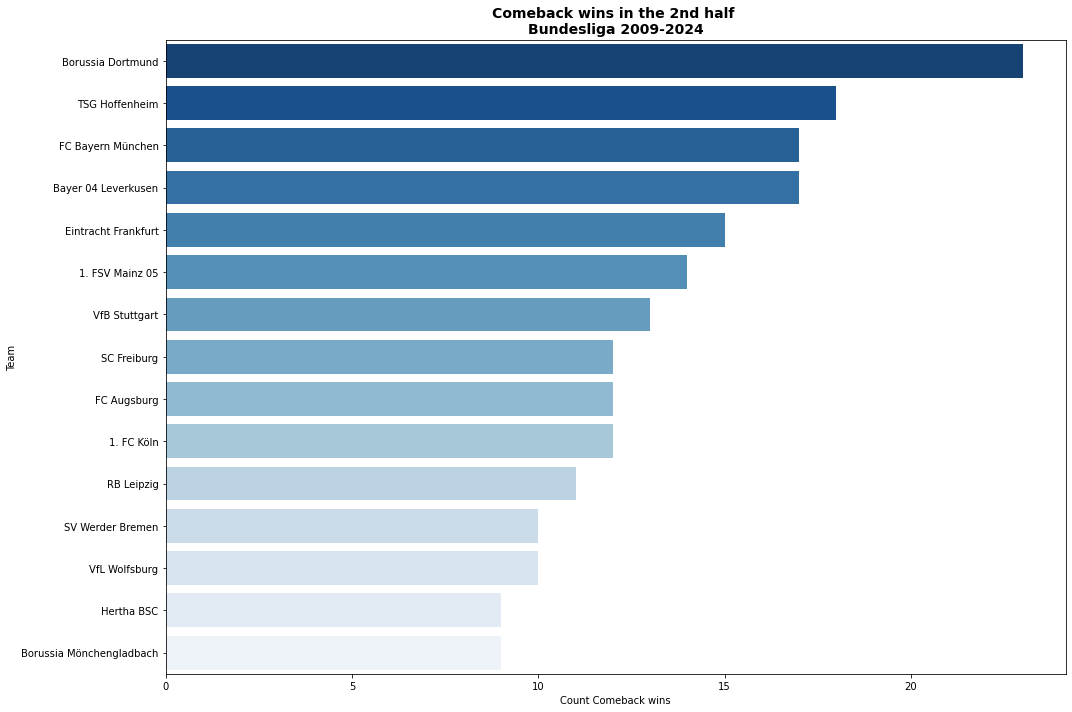

In [8]:
top15 = comeback_df.head(15)

plt.figure(figsize=(15, 10))
sns.barplot(data=top15, x="comeback_wins", y="team", palette="Blues_r")

plt.title(f"Comeback wins in the 2nd half \nBundesliga 2009-2024", 
          fontsize=14, fontweight="bold")
plt.xlabel("Count Comeback wins")
plt.ylabel("Team")
plt.tight_layout()
plt.show()

# Calculate comeback rate (wins after trailing / times trailing)

In [9]:

deficit_counts = {}

for i, row in df.iterrows():
    if row["ht_team1"] < row["ht_team2"]:
        deficit_counts[row["team1"]] = deficit_counts.get(row["team1"], 0) + 1
    if row["ht_team2"] < row["ht_team1"]:
        deficit_counts[row["team2"]] = deficit_counts.get(row["team2"], 0) + 1

comeback_df["halftime_deficits"] = comeback_df["team"].map(deficit_counts).fillna(0)
comeback_df["comeback_rate_%"] = (
    (comeback_df["comeback_wins"] / comeback_df["halftime_deficits"]) * 100
).round(1)

#only teams who were trailing at least 5 times are relevant
result = comeback_df[comeback_df["halftime_deficits"] >= 5].sort_values("comeback_rate_%", ascending=False)
print(result.head(10).to_string(index=False))

               team  comeback_wins  halftime_deficits  comeback_rate_%
  FC Bayern München             17                 66             25.8
  Borussia Dortmund             23                118             19.5
         RB Leipzig             11                 71             15.5
   FC Ingolstadt 04              3                 20             15.0
Bayer 04 Leverkusen             17                117             14.5
     TSG Hoffenheim             18                162             11.1
 1. FC Union Berlin              7                 63             11.1
Eintracht Frankfurt             15                149             10.1
      VfB Stuttgart             13                154              8.4
         1. FC Köln             12                144              8.3


# Slope graph to compare come back wins vs comeback rate

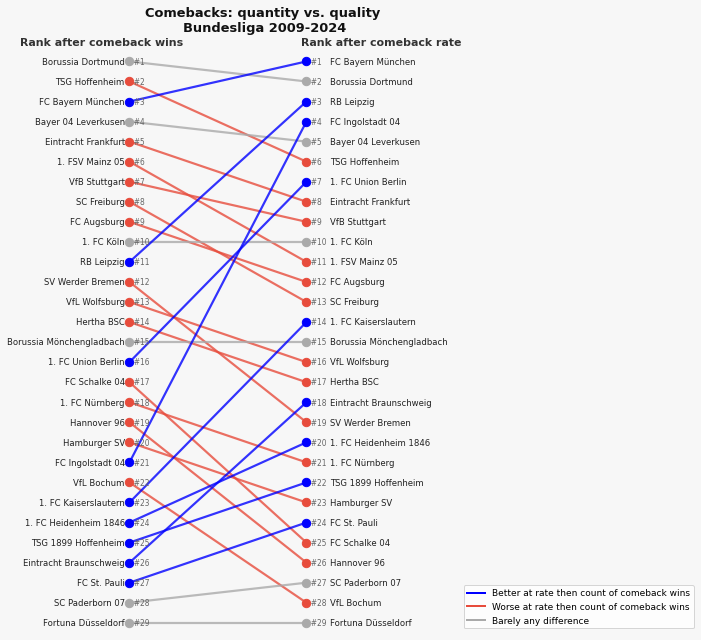

In [12]:
slope_df = comeback_df[comeback_df["halftime_deficits"] >= 5].copy()

# calculate ranks, 1= best. Fixed the overlap in ranks

slope_df["rank_wins"] = slope_df["comeback_wins"].rank(ascending=False, method='first').astype(int)
slope_df["rank_rate"] = slope_df["comeback_rate_%"].rank(ascending=False, method='first').astype(int)

# Classify as moved up / moved down / unchanged from comebackwins rankd to comeback rate rank
def classify(row):
    diff = row["rank_wins"] - row["rank_rate"]
    if diff > 1:   return "steigt", "#0000ff"   # Blue: better at rate
    if diff < -1:  return "fällt",  "#e74c3c"   # Rot: worse at Rate
    return "gleich", "#aaaaaa"                   # Grau: unchanged / not much changed 

slope_df[["movement", "color"]] = slope_df.apply(
    classify, axis=1, result_type="expand"
)


fig, ax = plt.subplots(figsize=(10, 9))
fig.patch.set_facecolor("#f7f7f7")
ax.set_facecolor("#f7f7f7")

n = len(slope_df)
ax.set_xlim(-0.5, 4)
ax.set_ylim(0.5, n + 0.5)

#Rowheading
ax.text(0,   n + 0.8, "Rank after comeback wins",  ha="center", fontsize=11,
        fontweight="bold", color="#333")
ax.text(3.0, n + 0.8, "Rank after comeback rate", ha="center", fontsize=11,
        fontweight="bold", color="#333")

for i, row in slope_df.iterrows():
    y_left  = n + 1 - row["rank_wins"]
    y_right = n + 1 - row["rank_rate"]
    c = row["color"]

    #connecting line
    ax.plot([0.3, 2.2], [y_left, y_right], color=c,
            linewidth=2.2, alpha=0.8, zorder=2)

    #connecting dots left and right
    ax.scatter([0.3], [y_left],  color=c, s=70, zorder=3)
    ax.scatter([2.2], [y_right], color=c, s=70, zorder=3)

    #teamnames left
    ax.text(0.25, y_left,  row["team"], ha="right", va="center",
            fontsize=8.5, color="#222")

    #teamnames right
    ax.text(2.45, y_right, row["team"], ha="left", va="center",
        fontsize=8.5, color="#222")

    #rank positions
    ax.text(0.3,  y_left,  f"  #{row['rank_wins']}", ha="left", va="center",
            fontsize=7.5, color="#666")
    ax.text(2.2,  y_right, f"  #{row['rank_rate']}", ha="left", va="center",
            fontsize=7.5, color="#666")



#
legend_elements = [
    mlines.Line2D([], [], color="#0000ff", linewidth=2,
                  label="Better at rate then count of comeback wins"),
    mlines.Line2D([], [], color="#e74c3c", linewidth=2,
                  label="Worse at rate then count of comeback wins"),
    mlines.Line2D([], [], color="#aaaaaa", linewidth=2,
                  label="Barely any difference"),
]
ax.legend(handles=legend_elements, loc="lower center",
          bbox_to_anchor=(1.25, 0.0), fontsize=9,
          facecolor="white", edgecolor="#ccc")

ax.axis("off")
ax.set_title(
    f"Comebacks: quantity vs. quality \nBundesliga 2009-2024",
    fontsize=13, fontweight="bold", color="#111", pad=20
)

plt.tight_layout()
plt.show()